## Section 1: Import Libraries & Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

print('✓ Libraries imported successfully!')
print(f'  - pandas: {pd.__version__}')
print(f'  - numpy: {np.__version__}')

✓ Libraries imported successfully!
  - pandas: 2.2.2
  - numpy: 1.26.4


In [3]:
# OPTION 2: BigQuery Extraction (OPTIONAL - Uncomment to use)
# Keep this code for reference, but CSV loading is preferred for performance

import pydata_google_auth
import pandas_gbq

# Uncomment this section to extract data from BigQuery:

SCOPES = ["https://www.googleapis.com/auth/bigquery"]

credentials = pydata_google_auth.get_user_credentials(
    SCOPES,
    auth_local_webserver=True,
)

query = '''
WITH excluded_users AS (
  SELECT DISTINCT user_id
  FROM `datamart.bbr_fraud_monitor`
  WHERE flag_indicator IN ('deleted user', 'blocked by DMD')
)

SELECT b1.*
FROM `L1.bbr_fact_ps_trip_score` b1
WHERE b1.eot = 'Y'
  -- This block ensures we get users from EITHER source
  AND (
    b1.user_id IN (
        1059, 1666, 1072, 1053, 1064, 1075, 1113, 2425, 1282, 1092, 
        1889, 1079, 11493, 1031, 1039, 1006, 8255, 1069, 19307, 19811, 
        1080, 2660, 11477, 1134, 1093, 1120, 1004, 1068, 2431, 15754, 
        1005, 187307, 1040, 1007, 1136, 1289, 1074, 183491, 1016, 1189, 
        1011, 13946, 32435, 1014, 180620, 2611, 1083, 17500, 1038, 1041, 
        2444, 146574, 1168, 187670, 1073
    )
  OR EXISTS (
      SELECT 1 
      FROM `L1.bbr_dim_user_xanh` u 
      WHERE u.user_id = b1.user_id
    )
  )
  -- This block ensures we still remove the 'bad' users from the results
  AND NOT EXISTS (
    SELECT 1 
    FROM excluded_users ex 
    WHERE ex.user_id = b1.user_id
  )
'''

df = pandas_gbq.read_gbq(
    query,
    project_id="lgi-dt-dwh",
    credentials=credentials,
)

# Save to CSV for faster subsequent loads
df.to_csv('trip_data_real_user.csv', index=False)
print(f'✓ Data extracted from BigQuery and saved to trip_data.csv: {df.shape}')


print('✓ BigQuery code available (commented out). Using CSV load by default.')

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=262006177488-3425ks60hkk80fssi9vpohv88g6q1iqd.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fbigquery&state=86xvwNX0BA5rNynOyas9IQCcZZnCj5&prompt=consent&access_type=offline
Downloading: 100%|██████████|
✓ Data extracted from BigQuery and saved to trip_data.csv: (61193, 34)
✓ BigQuery code available (commented out). Using CSV load by default.


In [4]:
# Load data id user from company from CSV
csv_path = Path('trip_data_real_user.csv')

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f'✓ Data loaded from CSV')
    print(f'  - Rows: {len(df):,}')
    print(f'  - Columns: {len(df.columns)}')
else:
    raise FileNotFoundError(f'{csv_path} not found')

✓ Data loaded from CSV
  - Rows: 61,193
  - Columns: 34


## Section 2: Feature Engineering (Recreate from v5)

This section reproduces the essential features needed for filtering.

In [5]:
# Haversine formula to calculate straight-line GPS distance
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two points on Earth using Haversine formula.
    Returns: Distance in kilometers
    """
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Calculate Haversine distance
df['distance_haversine'] = haversine(
    df['latitude_from'], 
    df['longitude_from'], 
    df['latitude_to'], 
    df['longitude_to']
)

print('✓ Haversine distance calculated')

✓ Haversine distance calculated


In [6]:
# Convert dates and calculate duration
df['driving_date_from'] = pd.to_datetime(df['driving_date_from'])
df['driving_date_to'] = pd.to_datetime(df['driving_date_to'])
df['trip_duration_seconds'] = (df['driving_date_to'] - df['driving_date_from']).dt.total_seconds()
df['trip_duration_minutes'] = df['trip_duration_seconds'] / 60

# Distance metrics
df['distance_diff_km'] = df['distance'] - df['distance_haversine']
df['distance_ratio'] = (df['distance'] / df['distance_haversine'].replace(0, np.nan))

# Average speed using driving_time (km/h)
df['avg_speed_kmh'] = df['distance'] / (df['driving_time'] / 3600).replace(0, np.nan)

print('✓ Features engineered:')
print('  - trip_duration_minutes')
print('  - distance_ratio')
print('  - avg_speed_kmh')

✓ Features engineered:
  - trip_duration_minutes
  - distance_ratio
  - avg_speed_kmh


## Section 3: Apply Filters

Apply the same quality filters to identify clean vs anomalous trips.

In [13]:
print("=" * 100)
print(" " * 30 + "🔍 APPLYING FILTERS FROM V5")
print("=" * 100)

# Apply quality filters
df_filtered = df[
    (df['distance'] > 0.5) &
    (df['trip_duration_minutes'] > 1) &
    (df['avg_speed_kmh'] > 0) & (df['avg_speed_kmh'] <= 100) &
    (df['trip_seq'] <= 3) &
    (df['distance_ratio'] <= 4.36) &
    (df['distance_diff_km'] > 0)
].copy()

print(f"\n📊 Filtering Results:")
print(f"  • Original Data: {len(df):,} trips")
print(f"  • Quality Filtered: {len(df_filtered):,} trips ({len(df_filtered)/len(df)*100:.1f}%)")
print(f"\n✅ Clean trips (passed all filters): {len(df_filtered):,}")
print(f"❌ Anomalous trips (failed any filter): {len(df) - len(df_filtered):,}")

                              🔍 APPLYING FILTERS FROM V5

📊 Filtering Results:
  • Original Data: 61,193 trips
  • Quality Filtered: 35,080 trips (57.3%)

✅ Clean trips (passed all filters): 35,080
❌ Anomalous trips (failed any filter): 26,113


In [23]:
print("=" * 135)
print(" " * 55 + "📊 TRIP ANOMALY ANALYSIS SUMMARY")
print("=" * 135)

# ============================================================================
# TABLE 1: DESCRIPTIVE STATISTICS FOR KEY METRICS (RAW DATA - df)
# ============================================================================
print("\n" + "=" * 135)
print("TABLE 1: DESCRIPTIVE STATISTICS FOR KEY TRIP METRICS (RAW DATA - df)")
print("=" * 135)

# Select key metrics
metrics = [
    'distance', 
    'trip_duration_minutes', 
    'distance_ratio', 
    'avg_speed_kmh', 
    'trip_seq',
    'distance_diff_km'
]

# Calculate descriptive statistics with selected percentiles
desc_stats = df[metrics].describe(percentiles=[.01, .25, .50, .75, .85]).T
desc_stats['mean'] = df[metrics].mean()
desc_stats['std'] = df[metrics].std()

# Calculate IQR bounds for outlier detection (Q1=0.25, Q3=0.75)
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['LB_IQR'] = desc_stats['25%'] - 1.5 * desc_stats['IQR']
desc_stats['UB_IQR'] = desc_stats['75%'] + 1.5 * desc_stats['IQR']

# Reorder columns for better readability
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '1%', '25%', '50%', '75%', '85%', 'max', 'LB_IQR', 'UB_IQR']]

# Rename columns to use P1, Q1, Q2, Q3, P85 naming convention
desc_stats.columns = ['count', 'mean', 'std', 'min', 'P1', 'Q1', 'Q2', 'Q3', 'P85', 'max', 'LB_IQR', 'UB_IQR']

# Format for display
desc_stats_display = desc_stats.copy()
desc_stats_display = desc_stats_display.round(2)

print("\n" + desc_stats_display.to_string())

print("\n📌 Key Observations (RAW DATA):")
print(f"  • Distance: Mean {desc_stats.loc['distance', 'mean']:.1f} km, Max {desc_stats.loc['distance', 'max']:.1f} km")
print(f"  • Duration: Mean {desc_stats.loc['trip_duration_minutes', 'mean']:.1f} min")
print(f"  • Distance Ratio: Mean {desc_stats.loc['distance_ratio', 'mean']:.2f}, Max {desc_stats.loc['distance_ratio', 'max']:.1f} (impossible)")
print(f"  • Speed: Mean {desc_stats.loc['avg_speed_kmh', 'mean']:.1f} km/h, extreme outliers detected")

# ============================================================================
# TABLE 2: DESCRIPTIVE STATISTICS FOR KEY METRICS (FILTERED DATA - df_filtered)
# ============================================================================
print("\n\n" + "=" * 135)
print("TABLE 2: DESCRIPTIVE STATISTICS FOR KEY TRIP METRICS (FILTERED DATA - df_filtered)")
print("=" * 135)

# Calculate descriptive stats for filtered data
desc_stats_filtered = df_filtered[metrics].describe(percentiles=[.01, .25, .50, .75, .85]).T
desc_stats_filtered['mean'] = df_filtered[metrics].mean()
desc_stats_filtered['std'] = df_filtered[metrics].std()

# Reorder columns for better readability
desc_stats_filtered = desc_stats_filtered[['count', 'mean', 'std', 'min', '1%', '25%', '50%', '75%', '85%', 'max']]

# Rename columns to use P1, Q1, Q2, Q3, P85 naming convention
desc_stats_filtered.columns = ['count', 'mean', 'std', 'min', 'P1', 'Q1', 'Q2', 'Q3', 'P85', 'max']

# Format for display
desc_stats_filtered_display = desc_stats_filtered.copy()
desc_stats_filtered_display = desc_stats_filtered_display.round(2)

print("\n" + desc_stats_filtered_display.to_string())

print("\n📌 Key Observations (FILTERED DATA):")
print(f"  • Distance: Mean {desc_stats_filtered.loc['distance', 'mean']:.1f} km, Max {desc_stats_filtered.loc['distance', 'max']:.1f} km")
print(f"  • Duration: Mean {desc_stats_filtered.loc['trip_duration_minutes', 'mean']:.1f} min")
print(f"  • Distance Ratio: Mean {desc_stats_filtered.loc['distance_ratio', 'mean']:.2f}, Max {desc_stats_filtered.loc['distance_ratio', 'max']:.2f} (normalized)")
print(f"  • Speed: Mean {desc_stats_filtered.loc['avg_speed_kmh', 'mean']:.1f} km/h, realistic range")

# ============================================================================

print("\n\n📊 SUMMARY STATISTICS:")
print(f"  • Raw data total records: {len(df):,}")
print(f"  • Filtered data total records: {len(df_filtered):,}")
print(f"  • Records removed: {len(df) - len(df_filtered):,} ({(len(df) - len(df_filtered))/len(df)*100:.1f}%)")
print(f"  • Records retained: {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")

print("\n💡 COLUMN NAMING EXPLANATION:")
print(f"  • count: Number of values")
print(f"  • mean: Average value")
print(f"  • std: Standard deviation")
print(f"  • min: Minimum value")
print(f"  • P1: 1st percentile (1% of data below this)")
print(f"  • Q1: 1st quartile / 25th percentile")
print(f"  • Q2: 2nd quartile / 50th percentile (Median)")
print(f"  • Q3: 3rd quartile / 75th percentile")
print(f"  • P85: 85th percentile (85% of data below this)")
print(f"  • max: Maximum value")
print(f"  • LB_IQR: Lower bound for outliers (Q1 - 1.5 × IQR)")
print(f"  • UB_IQR: Upper bound for outliers (Q3 + 1.5 × IQR)")


                                                       📊 TRIP ANOMALY ANALYSIS SUMMARY

TABLE 1: DESCRIPTIVE STATISTICS FOR KEY TRIP METRICS (RAW DATA - df)

                         count   mean      std       min    P1    Q1     Q2     Q3     P85        max  LB_IQR  UB_IQR
distance               61193.0  13.52    22.70      0.00  0.00  0.14   5.22  17.61   28.36     751.93  -26.07   43.82
trip_duration_minutes  61193.0  55.23    97.39      0.00  0.15  5.17  24.57  67.38  108.79    3718.18  -88.16  160.71
distance_ratio         59008.0  42.02   690.70      0.00  1.00  1.36   1.79   3.23    5.35   54839.69   -1.45    6.04
avg_speed_kmh          61163.0  60.72  1797.16      0.00  0.00  3.04  12.25  17.94   21.54  167499.74  -19.31   40.29
trip_seq               61193.0   1.02     0.18      1.00  1.00  1.00   1.00   1.00    1.00      11.00    1.00    1.00
distance_diff_km       61193.0   7.53    75.27 -10307.44 -0.00  0.05   1.79   7.92   15.71     508.59  -11.76   19.73

📌 Key Observati

In [ ]:
# ============================================================================
# CREATE FILTERED DATASET FOR ANALYSIS
# ============================================================================
# This filtered dataset is used by:
# - Cell 14: Distance ratio deep dive analysis
# - Cell 15: Anomaly detection (rule-based + IQR-based)
# - Cell 17: Comprehensive summary tables

print("=" * 100)
print(" " * 30 + "🔍 CREATING FILTERED DATASET FOR ANALYSIS")
print("=" * 100)

# Apply quality filters to create clean dataset
df_filtered_1 = df[
    (df['distance'] > 0.5) &
    (df['trip_duration_minutes'] > 1) &
    (df['avg_speed_kmh'] > 0) & (df['avg_speed_kmh'] <= 100) &
    (df['distance_diff_km'] > 0)
].copy()

# Create trip_seq <= 4 filtered dataset for analysis
df_filtered_seq4 = df_filtered_1[pd.to_numeric(df_filtered_1['trip_seq'], errors='coerce') <= 3].copy()

# Create additional filter with distance_ratio <= 4.36 to remove extreme outliers
df_filtered_seq4_ratio = df_filtered_seq4[df_filtered_seq4['distance_ratio'] <= 4.36].copy()

print(f"\n📊 Filtering Results:")
print(f"  • Original Data: {len(df):,} trips")
print(f"  • Filtered Data (Quality): {len(df_filtered_1):,} trips ({len(df_filtered_1)/len(df)*100:.1f}% retained)")
print(f"  • Filtered Data (Quality + trip_seq ≤ 3): {len(df_filtered_seq4):,} trips ({len(df_filtered_seq4)/len(df)*100:.1f}% of original, {len(df_filtered_seq4)/len(df_filtered_1)*100:.1f}% of quality-filtered)")
print(f"  • Filtered Data (Quality + trip_seq ≤ 3 + ratio ≤ 4.36): {len(df_filtered_seq4_ratio):,} trips ({len(df_filtered_seq4_ratio)/len(df)*100:.1f}% of original, {len(df_filtered_seq4_ratio)/len(df_filtered_seq4)*100:.1f}% of seq4-filtered)")
print(f"\n📌 Quality Filters Applied:")
print(f"  • Distance > 0.5 km")
print(f"  • Duration > 1 minute")

print(f"  • Speed: 0-100 km/h (realistic range)")
print(f"  • trip_seq ≤ 3 (for df_filtered_seq4)")
print(f"  • distance_ratio ≤ 4.36 (for df_filtered_seq4_ratio - removes extreme detour outliers)")
print(f"\n✅ df_filtered, df_filtered_seq4, and df_filtered_seq4_ratio are ready for downstream analysis")

                              🔍 CREATING FILTERED DATASET FOR ANALYSIS

📊 Filtering Results:
  • Original Data: 61,193 trips
  • Filtered Data (Quality): 42,555 trips (69.5% retained)
  • Filtered Data (Quality + trip_seq ≤ 3): 42,510 trips (69.5% of original, 99.9% of quality-filtered)
  • Filtered Data (Quality + trip_seq ≤ 3 + ratio ≤ 4.36): 35,080 trips (57.3% of original, 82.5% of seq4-filtered)

📌 Quality Filters Applied:
  • Distance > 0.5 km
  • Duration > 1 minute
  • Speed: 0-100 km/h (realistic range)
  • trip_seq ≤ 3 (for df_filtered_seq4)
  • distance_ratio ≤ 4.36 (for df_filtered_seq4_ratio - removes extreme detour outliers)

✅ df_filtered, df_filtered_seq4, and df_filtered_seq4_ratio are ready for downstream analysis


## Section 4: Create Anomaly Flag

Mark each trip as anomalous (1) or clean (0).

In [10]:
# Create anomaly flag column
# 1 = trip is anomalous (failed filters)
# 0 = trip is clean (passed all filters)

df['anomaly_flag'] = (~df['trip_id'].isin(df_filtered['trip_id'])).astype(int)

print("=" * 100)
print(" " * 35 + "🚩 ANOMALY FLAG CREATED")
print("=" * 100)

print(f"\n📊 Anomaly Flag Distribution:")
flag_counts = df['anomaly_flag'].value_counts()
print(f"  • Clean trips (flag=0): {flag_counts.get(0, 0):,} ({flag_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"  • Anomalous trips (flag=1): {flag_counts.get(1, 0):,} ({flag_counts.get(1, 0)/len(df)*100:.1f}%)")

# Verify
assert df['anomaly_flag'].sum() == (len(df) - len(df_filtered)), "Anomaly flag count mismatch!"
print(f"\n✅ Anomaly flag verified and ready for user analysis")

                                   🚩 ANOMALY FLAG CREATED

📊 Anomaly Flag Distribution:
  • Clean trips (flag=0): 31,296 (51.0%)
  • Anomalous trips (flag=1): 30,049 (49.0%)

✅ Anomaly flag verified and ready for user analysis


## Section 5: User-Level Aggregation (STEP 2)

Calculate user-level metrics: total trips, clean trips, anomalous trips, and infection rate.

In [11]:
print("=" * 100)
print(" " * 25 + "👥 USER-LEVEL AGGREGATION (STEP 2)")
print("=" * 100)

# Aggregate by user_id
user_stats = df.groupby('user_id').agg({
    'trip_id': 'count',                           # Total trips
    'anomaly_flag': 'sum',                        # Count anomalous trips (flag=1)
    'distance': ['mean', 'median'],               # Distance stats
    'distance_ratio': 'mean',                     # Avg detour ratio
    'avg_speed_kmh': 'mean',                      # Avg speed
    'trip_seq': 'median'                            # median trip sequence
}).reset_index()

# Flatten column names
user_stats.columns = ['user_id', 'total_trips', 'anomalous_trips', 
                       'avg_distance', 'median_distance', 'avg_distance_ratio', 
                       'avg_speed', 'median_trip_seq']

# Calculate derived metrics
user_stats['clean_trips'] = user_stats['total_trips'] - user_stats['anomalous_trips']
user_stats['anomaly_rate'] = (user_stats['anomalous_trips'] / user_stats['total_trips'] * 100).round(2)

# Determine infection status
user_stats['infection_status'] = user_stats['anomalous_trips'].apply(
    lambda x: 'NOT_INFECTED' if x == 0 else 'INFECTED'
)

# Categorize by risk level
def categorize_risk(rate):
    if rate < 20:
        return 'GREEN'
    elif rate < 50:
        return 'YELLOW'
    elif rate < 80:
        return 'ORANGE'
    else:
        return 'RED'

user_stats['risk_category'] = user_stats['anomaly_rate'].apply(categorize_risk)

# Sort by anomaly rate descending
user_stats = user_stats.sort_values('anomaly_rate', ascending=False).reset_index(drop=True)

print(f"\n📊 User Aggregation Complete:")
print(f"  • Total unique users: {len(user_stats):,}")
print(f"  • Total trips analyzed: {user_stats['total_trips'].sum():,}")
print(f"  • Total clean trips: {user_stats['clean_trips'].sum():,}")
print(f"  • Total anomalous trips: {user_stats['anomalous_trips'].sum():,}")

                         👥 USER-LEVEL AGGREGATION (STEP 2)

📊 User Aggregation Complete:
  • Total unique users: 859
  • Total trips analyzed: 61,345
  • Total clean trips: 31,296
  • Total anomalous trips: 30,049


## Section 6: Infection Status Summary

In [12]:
print("=" * 100)
print(" " * 25 + "🦠 INFECTION STATUS SUMMARY")
print("=" * 100)

# Count NOT_INFECTED vs INFECTED
not_infected = user_stats[user_stats['infection_status'] == 'NOT_INFECTED']
infected = user_stats[user_stats['infection_status'] == 'INFECTED']

print(f"\n✅ NOT_INFECTED USERS (0% anomaly rate):")
print(f"  • Count: {len(not_infected):,} users")
print(f"  • Percentage: {len(not_infected)/len(user_stats)*100:.1f}%")
print(f"  • Total trips from these users: {not_infected['total_trips'].sum():,}")
print(f"  • All trips are clean: {not_infected['clean_trips'].sum():,}")

print(f"\n🦠 INFECTED USERS (>0% anomaly rate):")
print(f"  • Count: {len(infected):,} users")
print(f"  • Percentage: {len(infected)/len(user_stats)*100:.1f}%")
print(f"  • Total trips from these users: {infected['total_trips'].sum():,}")
print(f"  • Clean trips: {infected['clean_trips'].sum():,}")
print(f"  • Anomalous trips: {infected['anomalous_trips'].sum():,}")

# Infection rate statistics
print(f"\n📈 Anomaly Rate Statistics (for INFECTED users):")
print(f"  • Min: {infected['anomaly_rate'].min():.2f}%")
print(f"  • Max: {infected['anomaly_rate'].max():.2f}%")
print(f"  • Mean: {infected['anomaly_rate'].mean():.2f}%")
print(f"  • Median: {infected['anomaly_rate'].median():.2f}%")
print(f"  • Std Dev: {infected['anomaly_rate'].std():.2f}%")

                         🦠 INFECTION STATUS SUMMARY

✅ NOT_INFECTED USERS (0% anomaly rate):
  • Count: 34 users
  • Percentage: 4.0%
  • Total trips from these users: 73
  • All trips are clean: 73

🦠 INFECTED USERS (>0% anomaly rate):
  • Count: 825 users
  • Percentage: 96.0%
  • Total trips from these users: 61,272
  • Clean trips: 31,223
  • Anomalous trips: 30,049

📈 Anomaly Rate Statistics (for INFECTED users):
  • Min: 3.57%
  • Max: 100.00%
  • Mean: 74.76%
  • Median: 100.00%
  • Std Dev: 31.62%


## Section 7: Risk Category Distribution

In [13]:
print("=" * 100)
print(" " * 28 + "🎯 RISK CATEGORY DISTRIBUTION")
print("=" * 100)

risk_distribution = user_stats[user_stats['infection_status'] == 'INFECTED'].groupby('risk_category').agg({
    'user_id': 'count',
    'total_trips': 'sum',
    'anomalous_trips': 'sum',
    'anomaly_rate': ['min', 'max', 'mean']
}).round(2)

risk_distribution.columns = ['user_count', 'total_trips', 'anomalous_trips', 'rate_min', 'rate_max', 'rate_mean']

# Define risk levels
risk_levels = {
    'GREEN': '0-20%',
    'YELLOW': '20-50%',
    'ORANGE': '50-80%',
    'RED': '80-100%'
}

print(f"\n🎨 Risk Category Breakdown:")
print(f"\n{'Category':10} {'Range':12} {'Users':10} {'%Users':10} {'Trips':12} {'Anomalies':12} {'Rate':12}")
print("-" * 100)

for category in ['GREEN', 'YELLOW', 'ORANGE', 'RED']:
    if category in risk_distribution.index:
        row = risk_distribution.loc[category]
        pct = row['user_count'] / len(infected) * 100
        print(f"{category:10} {risk_levels[category]:12} {int(row['user_count']):10} {pct:9.1f}% {int(row['total_trips']):12} {int(row['anomalous_trips']):12} {row['rate_mean']:11.1f}%")
    else:
        print(f"{category:10} {risk_levels[category]:12} {'0':10} {'0.0%':10} {'0':12} {'0':12} {'0.0%':12}")

print(f"\n📌 Interpretation:")
print(f"  • GREEN (0-20%): Likely legitimate with minor system errors")
print(f"  • YELLOW (20-50%): Moderate risk, needs review")
print(f"  • ORANGE (50-80%): High risk, likely fraudulent")
print(f"  • RED (80-100%): Very high risk, almost certainly fraudulent")

                            🎯 RISK CATEGORY DISTRIBUTION

🎨 Risk Category Breakdown:

Category   Range        Users      %Users     Trips        Anomalies    Rate        
----------------------------------------------------------------------------------------------------
GREEN      0-20%                51       6.2%        11388         1471        12.4%
YELLOW     20-50%              180      21.8%        25692         9370        35.0%
ORANGE     50-80%              109      13.2%        11922         7122        60.4%
RED        80-100%             485      58.8%        12270        12086        99.3%

📌 Interpretation:
  • GREEN (0-20%): Likely legitimate with minor system errors
  • YELLOW (20-50%): Moderate risk, needs review
  • ORANGE (50-80%): High risk, likely fraudulent
  • RED (80-100%): Very high risk, almost certainly fraudulent


## Section 8: Top Users by Risk

In [14]:
print("=" * 115)
print(" " * 35 + "⚠️ TOP 10 RISKIEST USERS (INFECTED ONLY)")
print("=" * 115)

infected_population = user_stats[user_stats['infection_status'] == 'INFECTED']

# Sort and get top 10 for the display table
infected_only = (infected_population
                 .sort_values(by=['anomaly_rate', 'total_trips'], ascending=[False, False])
                 .head(10))

print(f"\n{'Rank':5} {'User ID':10} {'Status':12} {'Risk':8} {'Total Trips':12} {'Clean Trips':12} {'Anomalous Trips':15} {'Rate':8} {'AvgDist':10} {'AvgSpeed':10}")
print("-" * 115)

for idx, (_, row) in enumerate(infected_only.iterrows(), 1):
    print(f"{idx:5} {int(row['user_id']):10} {row['infection_status']:12} {row['risk_category']:8} "
          f"{int(row['total_trips']):12} {int(row['clean_trips']):12} {int(row['anomalous_trips']):15} "
          f"{row['anomaly_rate']:7.1f}% {row['avg_distance']:9.2f} {row['avg_speed']:9.2f}")
    
print("=" * 115)

# 1. Find the maximum rate in the entire infected population
max_rate_value = infected_population['anomaly_rate'].max()

# 2. Count how many users have that exact rate
total_at_max = (infected_population['anomaly_rate'] == max_rate_value).sum()

print(f"SUMMARY: There are {total_at_max} infected users with the maximum anomaly rate of {max_rate_value:.1f}%.")
print("=" * 115)
print("\n")
print(" " * 35 + "⚠️ TOP 10 RISKIEST USERS BY TOTAL TRIPS (INFECTED ONLY)")
print("=" * 115)

infected_only = (infected_population
                 .sort_values(by=['total_trips', 'anomaly_rate', ], ascending=[False, False])
                 .head(10))

print(f"\n{'Rank':5} {'User ID':10} {'Status':12} {'Risk':8} {'Total Trips':12} {'Clean Trips':12} {'Anomalous Trips':15} {'Rate':8} {'AvgDist':10} {'AvgSpeed':10}")
print("-" * 115)

for idx, (_, row) in enumerate(infected_only.iterrows(), 1):
    print(f"{idx:5} {int(row['user_id']):10} {row['infection_status']:12} {row['risk_category']:8} "
          f"{int(row['total_trips']):12} {int(row['clean_trips']):12} {int(row['anomalous_trips']):15} "
          f"{row['anomaly_rate']:7.1f}% {row['avg_distance']:9.2f} {row['avg_speed']:9.2f}")
    

                                   ⚠️ TOP 10 RISKIEST USERS (INFECTED ONLY)

Rank  User ID    Status       Risk     Total Trips  Clean Trips  Anomalous Trips Rate     AvgDist    AvgSpeed  
-------------------------------------------------------------------------------------------------------------------
    1       3262 INFECTED     RED                55            0              55   100.0%    171.86  29624.50
    2      12623 INFECTED     RED                55            0              55   100.0%    530.31 307436.11
    3      12613 INFECTED     RED                53            0              53   100.0%    365.52 174612.95
    4      15772 INFECTED     RED                52            0              52   100.0%    352.43  42673.52
    5      15754 INFECTED     RED                51            0              51   100.0%    273.20  46679.64
    6       3255 INFECTED     RED                50            0              50   100.0%    668.52 110551.38
    7       3238 INFECTED     RED  

## Section 9: Analysis by Trip Volume

In [15]:
print("=" * 100)
print(" " * 30 + "📊 ANALYSIS BY TRIP VOLUME")
print("=" * 100)

# Create trip volume categories
user_stats['trip_volume_category'] = pd.cut(
    user_stats['total_trips'],
    bins=[0, 10, 30, 50, 100, float('inf')],
    labels=['1-10 trips', '11-30 trips', '31-50 trips', '51-100 trips', '100+ trips']
)

volume_analysis = user_stats.groupby('trip_volume_category', observed=True).agg({
    'user_id': 'count',
    'total_trips': 'sum',
    'anomalous_trips': 'sum',
    'anomaly_rate': 'mean',
    'infection_status': lambda x: (x == 'INFECTED').sum()
}).round(2)

volume_analysis.columns = ['user_count', 'total_trips', 'anomalous_trips', 'avg_anomaly_rate', 'infected_count']
volume_analysis['infection_pct'] = (volume_analysis['infected_count'] / volume_analysis['user_count'] * 100).round(1)

print(f"\n{'Trip Volume':15} {'Users':10} {'Infected':10} {'Infected%':10} {'Total Trips':15} {'Avg Rate':12}")
print("-" * 100)

for category in volume_analysis.index:
    row = volume_analysis.loc[category]
    print(f"{str(category):15} {int(row['user_count']):10} {int(row['infected_count']):10} "
          f"{row['infection_pct']:9.1f}% {int(row['total_trips']):15} {row['avg_anomaly_rate']:11.1f}%")

print(f"\n📈 Insight: Does trip volume correlate with anomaly risk?")

                              📊 ANALYSIS BY TRIP VOLUME

Trip Volume     Users      Infected   Infected%  Total Trips     Avg Rate    
----------------------------------------------------------------------------------------------------
1-10 trips             220        186      84.5%             869        62.5%
11-30 trips            386        386     100.0%            8404        92.6%
31-50 trips             69         69     100.0%            2729        69.5%
51-100 trips            57         57     100.0%            4044        43.6%
100+ trips             127        127     100.0%           45299        38.6%

📈 Insight: Does trip volume correlate with anomaly risk?


## Section 10: Visualizations

✅ Visualization saved to outputs/user_anomaly_analysis.png


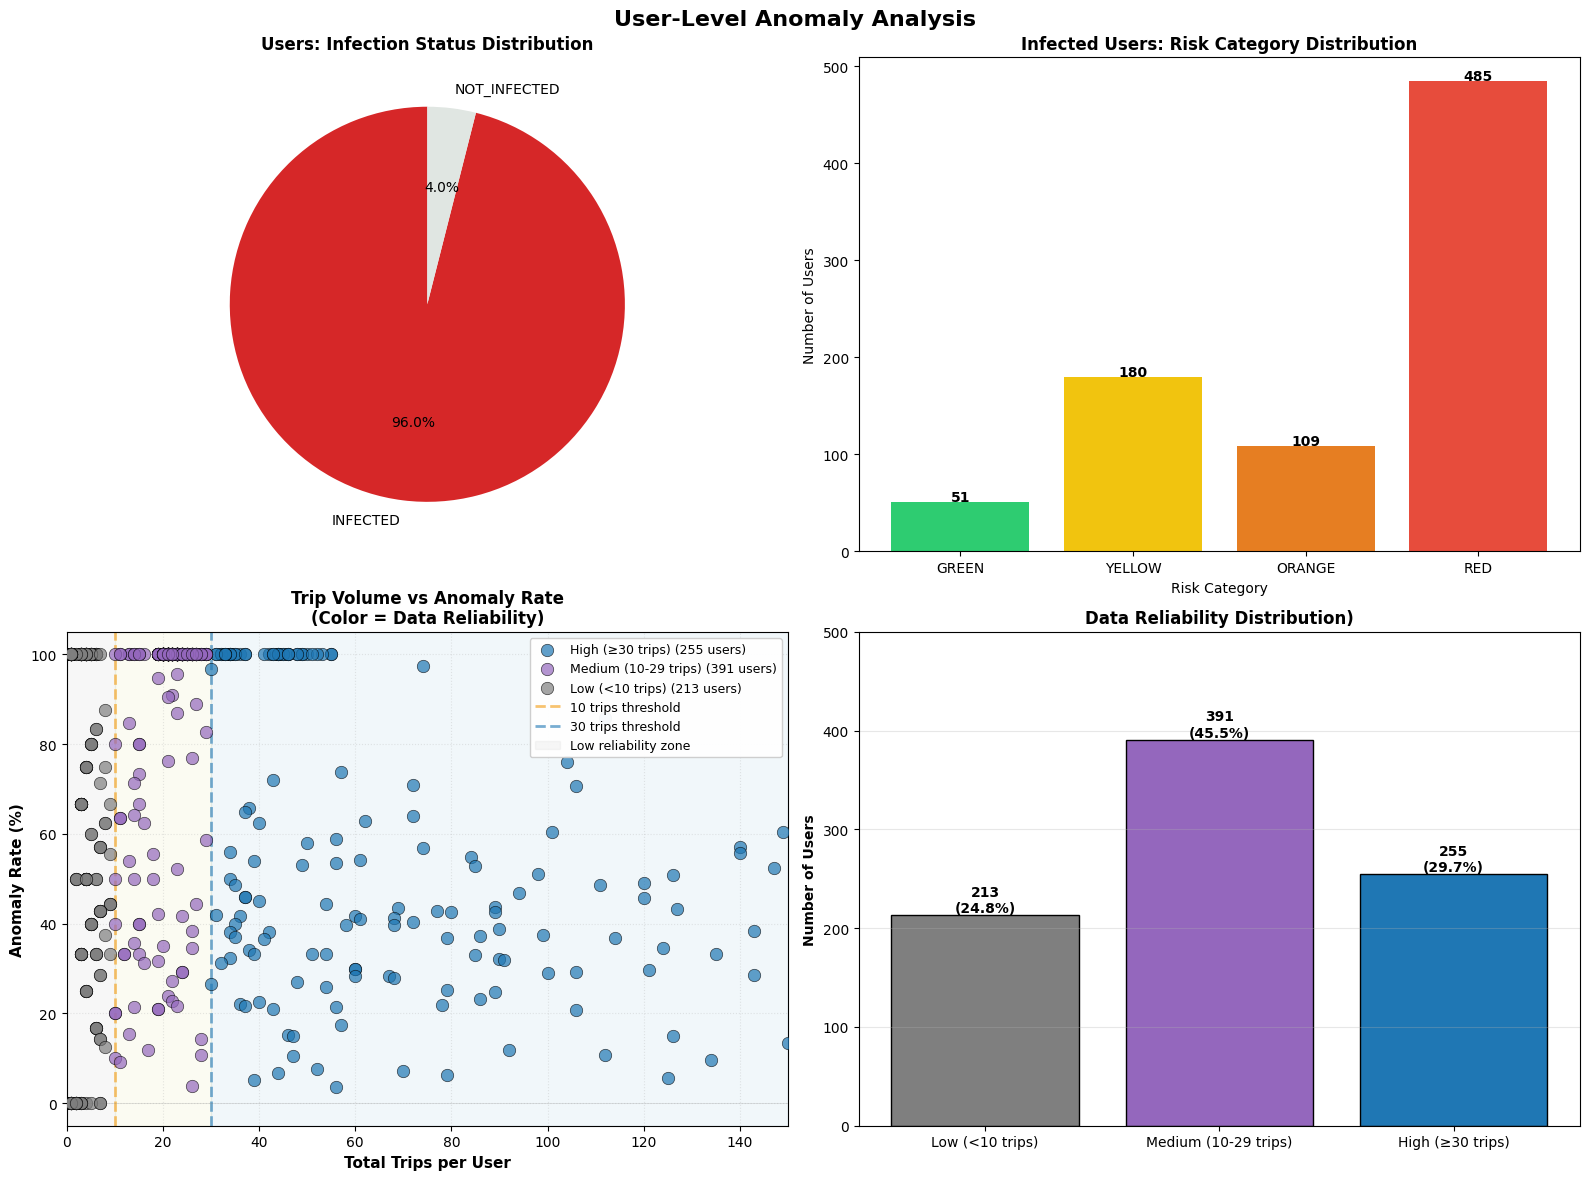


                    📊 DATA RELIABILITY ANALYSIS

Low (<10 trips):
  • Users: 213 (24.8%)
  • Infected: 179 (84.0%)
  • Avg anomaly rate: 63.09%
  • Total trips: 799
  • Data quality: 🚨 UNRELIABLE

Medium (10-29 trips):
  • Users: 391 (45.5%)
  • Infected: 391 (100.0%)
  • Avg anomaly rate: 91.90%
  • Total trips: 8,414
  • Data quality: ⚠️ MODERATE

High (≥30 trips):
  • Users: 255 (29.7%)
  • Infected: 255 (100.0%)
  • Avg anomaly rate: 48.25%
  • Total trips: 52,132
  • Data quality: ✅ RELIABLE



In [16]:
# Create enhanced visualizations with sample-size reliability awareness (distinct palettes per chart)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('User-Level Anomaly Analysis', fontsize=16, fontweight='bold')

infected_users = user_stats[user_stats['infection_status'] == 'INFECTED']

# Define reliability thresholds

def get_reliability_level(trips):
    """Categorize users by data reliability based on trip count"""
    if trips >= 30:
        return 'High (≥30 trips)'
    elif trips >= 10:
        return 'Medium (10-29 trips)'
    else:
        return 'Low (<10 trips)'

user_stats['reliability_level'] = user_stats['total_trips'].apply(get_reliability_level)

# Infection status: RED (infected) vs Pale WHITE (not infected)
status_colors_map = {
    'INFECTED': '#d62728',     # Red
    'NOT_INFECTED': "#e0e6e2"  # Pale WHITE
}

# Risk categories: standard green→yellow→orange→red
colors_risk = ["#2ecc71", '#f1c40f', '#e67e22', '#e74c3c']

# Reliability levels: BLUE (high), PURPLE (medium), GRAY (low)
reliability_colors = {
    'High (≥30 trips)': '#1f77b4',    # Blue
    'Medium (10-29 trips)': '#9467bd', # Purple
    'Low (<10 trips)': '#7f7f7f'      # Gray
}

# Reliability distribution bars: grayscale
colors_rel = ['#7f7f7f', '#9467bd', '#1f77b4']

# 1. Infection Status Distribution (Pie Chart)
ax1 = axes[0, 0]
infection_counts = user_stats['infection_status'].value_counts()
colors_status = [status_colors_map[label] for label in infection_counts.index]
ax1.pie(
    infection_counts.values,
    labels=infection_counts.index,
    autopct='%1.1f%%',
    colors=colors_status,
    startangle=90
)
ax1.set_title('Users: Infection Status Distribution', fontweight='bold', fontsize=12)

# 2. Risk Category Distribution (Bar Chart)
ax2 = axes[0, 1]
risk_counts = infected_users['risk_category'].value_counts().reindex(['GREEN', 'YELLOW', 'ORANGE', 'RED'], fill_value=0)
ax2.bar(risk_counts.index, risk_counts.values, color=colors_risk)
ax2.set_title('Infected Users: Risk Category Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Number of Users')
ax2.set_xlabel('Risk Category')
for i, v in enumerate(risk_counts.values):
    ax2.text(i, v + 1, str(int(v)), ha='center', fontweight='bold')

# 3. Enhanced Scatter Plot - Color-coded
ax3 = axes[1, 0]
for reliability, color in reliability_colors.items():
    subset = user_stats[user_stats['reliability_level'] == reliability]
    ax3.scatter(
        subset['total_trips'], subset['anomaly_rate'],
        alpha=0.7, s=80, color=color, edgecolors='black', linewidth=0.5,
        label=f'{reliability} ({len(subset):,} users)', zorder=3
    )

X_LIMIT = 150 # Change this number to whatever you prefer
ax3.set_xlim(left=0, right=X_LIMIT)
# Threshold lines and shaded zones
ax3.axvline(x=10, color='#f39c12', linestyle='--', linewidth=2, alpha=0.6, label='10 trips threshold')
ax3.axvline(x=30, color='#1f77b4', linestyle='--', linewidth=2, alpha=0.6, label='30 trips threshold')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax3.axvspan(0, 10, alpha=0.06, color='#7f7f7f', label='Low reliability zone')
ax3.axvspan(10, 30, alpha=0.06, color='#bcbd22')
ax3.axvspan(30, X_LIMIT, alpha=0.06, color='#1f77b4')

ax3.set_xlabel('Total Trips per User', fontsize=11, fontweight='bold')
ax3.set_ylabel('Anomaly Rate (%)', fontsize=11, fontweight='bold')
ax3.set_title('Trip Volume vs Anomaly Rate\n(Color = Data Reliability)', fontweight='bold', fontsize=12)
ax3.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax3.grid(True, alpha=0.3, linestyle=':')
ax3.set_xlim(left=0)

# 4. Sample Size Reliability Distribution (Bar Chart)
ax4 = axes[1, 1]
reliability_counts = user_stats.groupby('reliability_level').agg({
    'user_id': 'count',
    'total_trips': 'sum',
    'anomalous_trips': 'sum',
    'anomaly_rate': 'mean'
}).round(2)
reliability_order = ['Low (<10 trips)', 'Medium (10-29 trips)', 'High (≥30 trips)']
reliability_counts = reliability_counts.reindex(reliability_order)

bars = ax4.bar(range(len(reliability_counts)), reliability_counts['user_id'], color=colors_rel, edgecolor='black', linewidth=1)
ax4.set_xticks(range(len(reliability_counts)))
ax4.set_xticklabels(reliability_order, fontsize=10)
ax4.set_ylim(0, 500)
ax4.set_ylabel('Number of Users', fontweight='bold')
ax4.set_title('Data Reliability Distribution)', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y')
for i, (bar, count) in enumerate(zip(bars, reliability_counts['user_id'])):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count):,}\n({count/len(user_stats)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/user_anomaly_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved to outputs/user_anomaly_analysis.png")
plt.show()

# Print reliability summary
print("\n" + "=" * 100)
print(" " * 20 + "📊 DATA RELIABILITY ANALYSIS")
print("=" * 100)
for level in reliability_order:
    subset = user_stats[user_stats['reliability_level'] == level]
    infected_count = len(subset[subset['infection_status'] == 'INFECTED'])
    print(f"\n{level}:")
    print(f"  • Users: {len(subset):,} ({len(subset)/len(user_stats)*100:.1f}%)")
    print(f"  • Infected: {infected_count:,} ({infected_count/len(subset)*100:.1f}%)")
    print(f"  • Avg anomaly rate: {subset['anomaly_rate'].mean():.2f}%")
    print(f"  • Total trips: {subset['total_trips'].sum():,}")
    print(f"  • Data quality: {'✅ RELIABLE' if 'High' in level else '⚠️ MODERATE' if 'Medium' in level else '🚨 UNRELIABLE'}")
print(f"\n" + "=" * 100)


## Section 10.1: Bubble Chart - Volume-Aware Risk Analysis

Visualize user risk with 3 dimensions simultaneously:
- **X-axis**: Total trips (activity volume)
- **Y-axis**: Anomaly rate (% of anomalous trips)
- **Bubble size**: Absolute count of anomalous trips (the TRUE metric of concern)

This solves the small-sample-size problem by showing you can't hide large anomaly counts behind small percentages.

                    🫧 BUBBLE CHART: 3D VOLUME-AWARE RISK ANALYSIS

✅ Bubble chart saved to outputs/bubble_chart_3d_risk_analysis.png


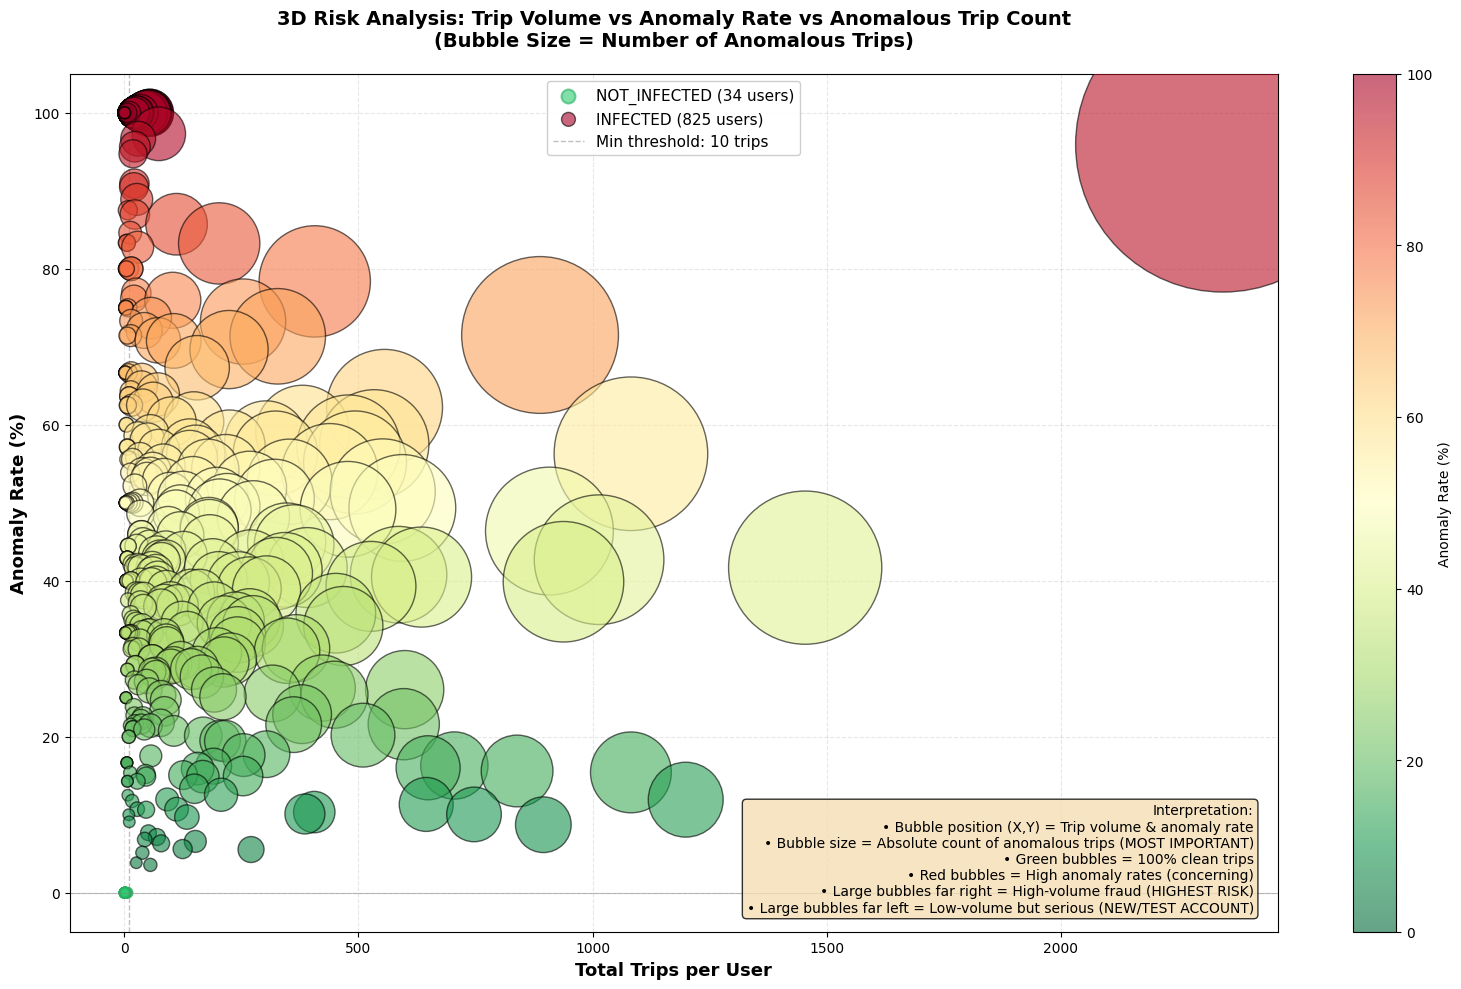


                         📊 BUBBLE CHART INTERPRETATION

🎯 USER RISK PROFILES (by position in bubble chart):

1️⃣ HIGH VOLUME + HIGH RATE (Top Right) - 🚨 CRITICAL FRAUD:
   • Users: 54
   • Avg trips: 263
   • Avg anomaly rate: 66.4%
   • Total anomalous trips: 9,556
   • Risk: PROFESSIONAL FRAUDSTERS - systematic, large-scale fraud

2️⃣ LOW VOLUME + HIGH RATE (Top Left) - ⚠️ SUSPICIOUS NEW ACCOUNTS:
   • Users: 98
   • Avg trips: 3
   • Avg anomaly rate: 98.5%
   • Total anomalous trips: 304
   • Risk: LIKELY FRAUDULENT TEST ACCOUNTS - multiple failed attempts

3️⃣ HIGH VOLUME + LOW RATE (Bottom Right) - ✅ LIKELY LEGITIMATE:
   • Users: 32
   • Avg trips: 343
   • Avg anomaly rate: 12.4%
   • Total anomalous trips: 1,426
   • Risk: LOW - Real drivers with occasional system errors

4️⃣ MEDIUM VOLUME + MEDIUM RATE (Middle) - 🔍 REQUIRES REVIEW:
   • Users: 47
   • Avg trips: 27
   • Avg anomaly rate: 32.8%
   • Total anomalous trips: 421
   • Risk: UNCERTAIN - could be legitimate or frau

In [17]:
print("=" * 100)
print(" " * 20 + "🫧 BUBBLE CHART: 3D VOLUME-AWARE RISK ANALYSIS")
print("=" * 100)

# Create bubble chart
fig, ax = plt.subplots(figsize=(16, 10))

# Separate data by infection status
not_infected_data = user_stats[user_stats['infection_status'] == 'NOT_INFECTED']
infected_data = user_stats[user_stats['infection_status'] == 'INFECTED']

# Plot NOT_INFECTED users (all have 0% anomaly rate)
if len(not_infected_data) > 0:
    ax.scatter(
        not_infected_data['total_trips'],
        not_infected_data['anomaly_rate'],
        s=not_infected_data['anomalous_trips'] * 100 + 50,  # Bubble size (min 50 for visibility)
        alpha=0.6,
        color='#2ecc71',  # Green
        edgecolors='#27ae60',
        linewidth=1.5,
        label=f'NOT_INFECTED ({len(not_infected_data):,} users)',
        zorder=2
    )

# Plot INFECTED users with color gradient based on anomaly rate
if len(infected_data) > 0:
    scatter = ax.scatter(
        infected_data['total_trips'],
        infected_data['anomaly_rate'],
        s=infected_data['anomalous_trips'] * 20 + 50,  # Bubble size scales with anomalous trip count
        c=infected_data['anomaly_rate'],  # Color gradient
        cmap='RdYlGn_r',  # Red (high) to Green (low)
        alpha=0.6,
        edgecolors='black',
        linewidth=1,
        label=f'INFECTED ({len(infected_data):,} users)',
        vmin=0,
        vmax=100,
        zorder=3
    )
    
    # Add colorbar for anomaly rate
    cbar = plt.colorbar(scatter, ax=ax, label='Anomaly Rate (%)')

# Customize axes
ax.set_xlabel('Total Trips per User', fontsize=13, fontweight='bold')
ax.set_ylabel('Anomaly Rate (%)', fontsize=13, fontweight='bold')
ax.set_title('3D Risk Analysis: Trip Volume vs Anomaly Rate vs Anomalous Trip Count\n(Bubble Size = Number of Anomalous Trips)', 
             fontsize=14, fontweight='bold', pad=20)

# Grid for readability
ax.grid(True, alpha=0.3, linestyle='--')

# Add reference lines
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Min threshold: 10 trips')

# Legend
leg = ax.legend(loc='upper center', fontsize=11, framealpha=0.95 )

for handle in leg.legend_handles:
    # Check if it's a scatter-type handle
    if hasattr(handle, 'set_sizes'):
        handle.set_sizes([100.0])
    # Check if it's a line-type handle
    elif hasattr(handle, 'set_markersize'):
        handle.set_markersize(10)

# Add interpretation text
textstr = ('Interpretation:\n'
           '• Bubble position (X,Y) = Trip volume & anomaly rate\n'
           '• Bubble size = Absolute count of anomalous trips (MOST IMPORTANT)\n'
           '• Green bubbles = 100% clean trips\n'
           '• Red bubbles = High anomaly rates (concerning)\n'
           '• Large bubbles far right = High-volume fraud (HIGHEST RISK)\n'
           '• Large bubbles far left = Low-volume but serious (NEW/TEST ACCOUNT)')
ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('outputs/bubble_chart_3d_risk_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Bubble chart saved to outputs/bubble_chart_3d_risk_analysis.png")
plt.show()

print(f"\n" + "=" * 100)
print(f" " * 25 + "📊 BUBBLE CHART INTERPRETATION")
print(f"=" * 100)

# Identify different risk profiles
print(f"\n🎯 USER RISK PROFILES (by position in bubble chart):\n")

# High volume, high rate (top right) - MOST DANGEROUS
high_vol_high_rate = infected_data[(infected_data['total_trips'] >= 50) & (infected_data['anomaly_rate'] >= 50)]
print(f"1️⃣ HIGH VOLUME + HIGH RATE (Top Right) - 🚨 CRITICAL FRAUD:")
print(f"   • Users: {len(high_vol_high_rate):,}")
if len(high_vol_high_rate) > 0:
    print(f"   • Avg trips: {high_vol_high_rate['total_trips'].mean():.0f}")
    print(f"   • Avg anomaly rate: {high_vol_high_rate['anomaly_rate'].mean():.1f}%")
    print(f"   • Total anomalous trips: {high_vol_high_rate['anomalous_trips'].sum():,}")
    print(f"   • Risk: PROFESSIONAL FRAUDSTERS - systematic, large-scale fraud")
else:
    print(f"   • None found - Good sign!")

# Low volume, high rate (top left) - TEST ACCOUNTS
low_vol_high_rate = infected_data[(infected_data['total_trips'] < 10) & (infected_data['anomaly_rate'] >= 80)]
print(f"\n2️⃣ LOW VOLUME + HIGH RATE (Top Left) - ⚠️ SUSPICIOUS NEW ACCOUNTS:")
print(f"   • Users: {len(low_vol_high_rate):,}")
if len(low_vol_high_rate) > 0:
    print(f"   • Avg trips: {low_vol_high_rate['total_trips'].mean():.0f}")
    print(f"   • Avg anomaly rate: {low_vol_high_rate['anomaly_rate'].mean():.1f}%")
    print(f"   • Total anomalous trips: {low_vol_high_rate['anomalous_trips'].sum():,}")
    print(f"   • Risk: LIKELY FRAUDULENT TEST ACCOUNTS - multiple failed attempts")
else:
    print(f"   • None found - Good sign!")

# High volume, low rate (bottom right) - LEGITIMATE OR OCCASIONAL ERRORS
high_vol_low_rate = infected_data[(infected_data['total_trips'] >= 50) & (infected_data['anomaly_rate'] < 20)]
print(f"\n3️⃣ HIGH VOLUME + LOW RATE (Bottom Right) - ✅ LIKELY LEGITIMATE:")
print(f"   • Users: {len(high_vol_low_rate):,}")
if len(high_vol_low_rate) > 0:
    print(f"   • Avg trips: {high_vol_low_rate['total_trips'].mean():.0f}")
    print(f"   • Avg anomaly rate: {high_vol_low_rate['anomaly_rate'].mean():.1f}%")
    print(f"   • Total anomalous trips: {high_vol_low_rate['anomalous_trips'].sum():,}")
    print(f"   • Risk: LOW - Real drivers with occasional system errors")
else:
    print(f"   • None found")

# Medium range
medium_vol_medium_rate = infected_data[
    (infected_data['total_trips'] >= 10) & (infected_data['total_trips'] < 50) & 
    (infected_data['anomaly_rate'] >= 20) & (infected_data['anomaly_rate'] < 50)
]
print(f"\n4️⃣ MEDIUM VOLUME + MEDIUM RATE (Middle) - 🔍 REQUIRES REVIEW:")
print(f"   • Users: {len(medium_vol_medium_rate):,}")
if len(medium_vol_medium_rate) > 0:
    print(f"   • Avg trips: {medium_vol_medium_rate['total_trips'].mean():.0f}")
    print(f"   • Avg anomaly rate: {medium_vol_medium_rate['anomaly_rate'].mean():.1f}%")
    print(f"   • Total anomalous trips: {medium_vol_medium_rate['anomalous_trips'].sum():,}")
    print(f"   • Risk: UNCERTAIN - could be legitimate or fraudulent")
else:
    print(f"   • None found")

print(f"\n" + "=" * 100)


## Section 10.5: Deep Dive - User with Most Trips

Analyze the user with the highest trip volume to understand their anomaly distribution in detail.

In [18]:
print("=" * 100)
print(" " * 20 + "🔍 DEEP DIVE: USER WITH MOST TRIPS - ANOMALY DISTRIBUTION")
print("=" * 100)

# Find user with most trips
top_user_id = user_stats.loc[user_stats['total_trips'].idxmax(), 'user_id']
top_user_stats = user_stats[user_stats['user_id'] == top_user_id].iloc[0]

print(f"\n📊 User with Most Trips: User {int(top_user_id)}")
print(f"  • Total trips: {int(top_user_stats['total_trips'])}")
print(f"  • Clean trips: {int(top_user_stats['clean_trips'])}")
print(f"  • Anomalous trips: {int(top_user_stats['anomalous_trips'])}")
print(f"  • Anomaly rate: {top_user_stats['anomaly_rate']:.2f}%")
print(f"  • Infection status: {top_user_stats['infection_status']}")
print(f"  • Risk category: {top_user_stats['risk_category']}")

# Get all trips for this user
top_user_trips = df[df['user_id'] == top_user_id].copy()

print(f"\n📈 Trip Distribution for User {int(top_user_id)}:")
print(f"  • Total records: {len(top_user_trips):,}")
print(f"  • Clean (anomaly_flag=0): {(top_user_trips['anomaly_flag'] == 0).sum():,}")
print(f"  • Anomalous (anomaly_flag=1): {(top_user_trips['anomaly_flag'] == 1).sum():,}")

# Analyze which filters failed for anomalous trips
anomalous_trips_user = top_user_trips[top_user_trips['anomaly_flag'] == 1].copy()

print(f"\n🚩 Anomaly Breakdown for User {int(top_user_id)}:")
if len(anomalous_trips_user) > 0:
    # Categorize failures
    too_short_dist = (anomalous_trips_user['distance'] <= 0.5).sum()
    too_short_dur = (anomalous_trips_user['trip_duration_minutes'] <= 1).sum()
    high_speed = (anomalous_trips_user['avg_speed_kmh'] > 100).sum()
    invalid_speed = (anomalous_trips_user['avg_speed_kmh'] <= 0) | anomalous_trips_user['avg_speed_kmh'].isna()
    invalid_speed = invalid_speed.sum()
    high_seq = (anomalous_trips_user['trip_seq'] > 3).sum()
    high_ratio = (anomalous_trips_user['distance_ratio'] > 4.36).sum()
    
    print(f"  • Distance ≤ 0.5 km: {too_short_dist}")
    print(f"  • Duration ≤ 1 min: {too_short_dur}")
    print(f"  • Speed > 100 km/h: {high_speed}")
    print(f"  • Invalid speed (≤0 or NaN): {invalid_speed}")
    print(f"  • trip_seq > 3: {high_seq}")
    print(f"  • distance_ratio > 4.36: {high_ratio}")
else:
    print(f"  • User has no anomalous trips")


                    🔍 DEEP DIVE: USER WITH MOST TRIPS - ANOMALY DISTRIBUTION

📊 User with Most Trips: User 186245
  • Total trips: 2346
  • Clean trips: 96
  • Anomalous trips: 2250
  • Anomaly rate: 95.91%
  • Infection status: INFECTED
  • Risk category: RED

📈 Trip Distribution for User 186245:
  • Total records: 2,346
  • Clean (anomaly_flag=0): 96
  • Anomalous (anomaly_flag=1): 2,250

🚩 Anomaly Breakdown for User 186245:
  • Distance ≤ 0.5 km: 2223
  • Duration ≤ 1 min: 2207
  • Speed > 100 km/h: 1
  • Invalid speed (≤0 or NaN): 448
  • trip_seq > 3: 0
  • distance_ratio > 4.36: 58



                         📊 VISUALIZATIONS: USER 186245'S TRIP DISTRIBUTION

✅ Visualization saved to outputs/top_user_trip_distribution.png


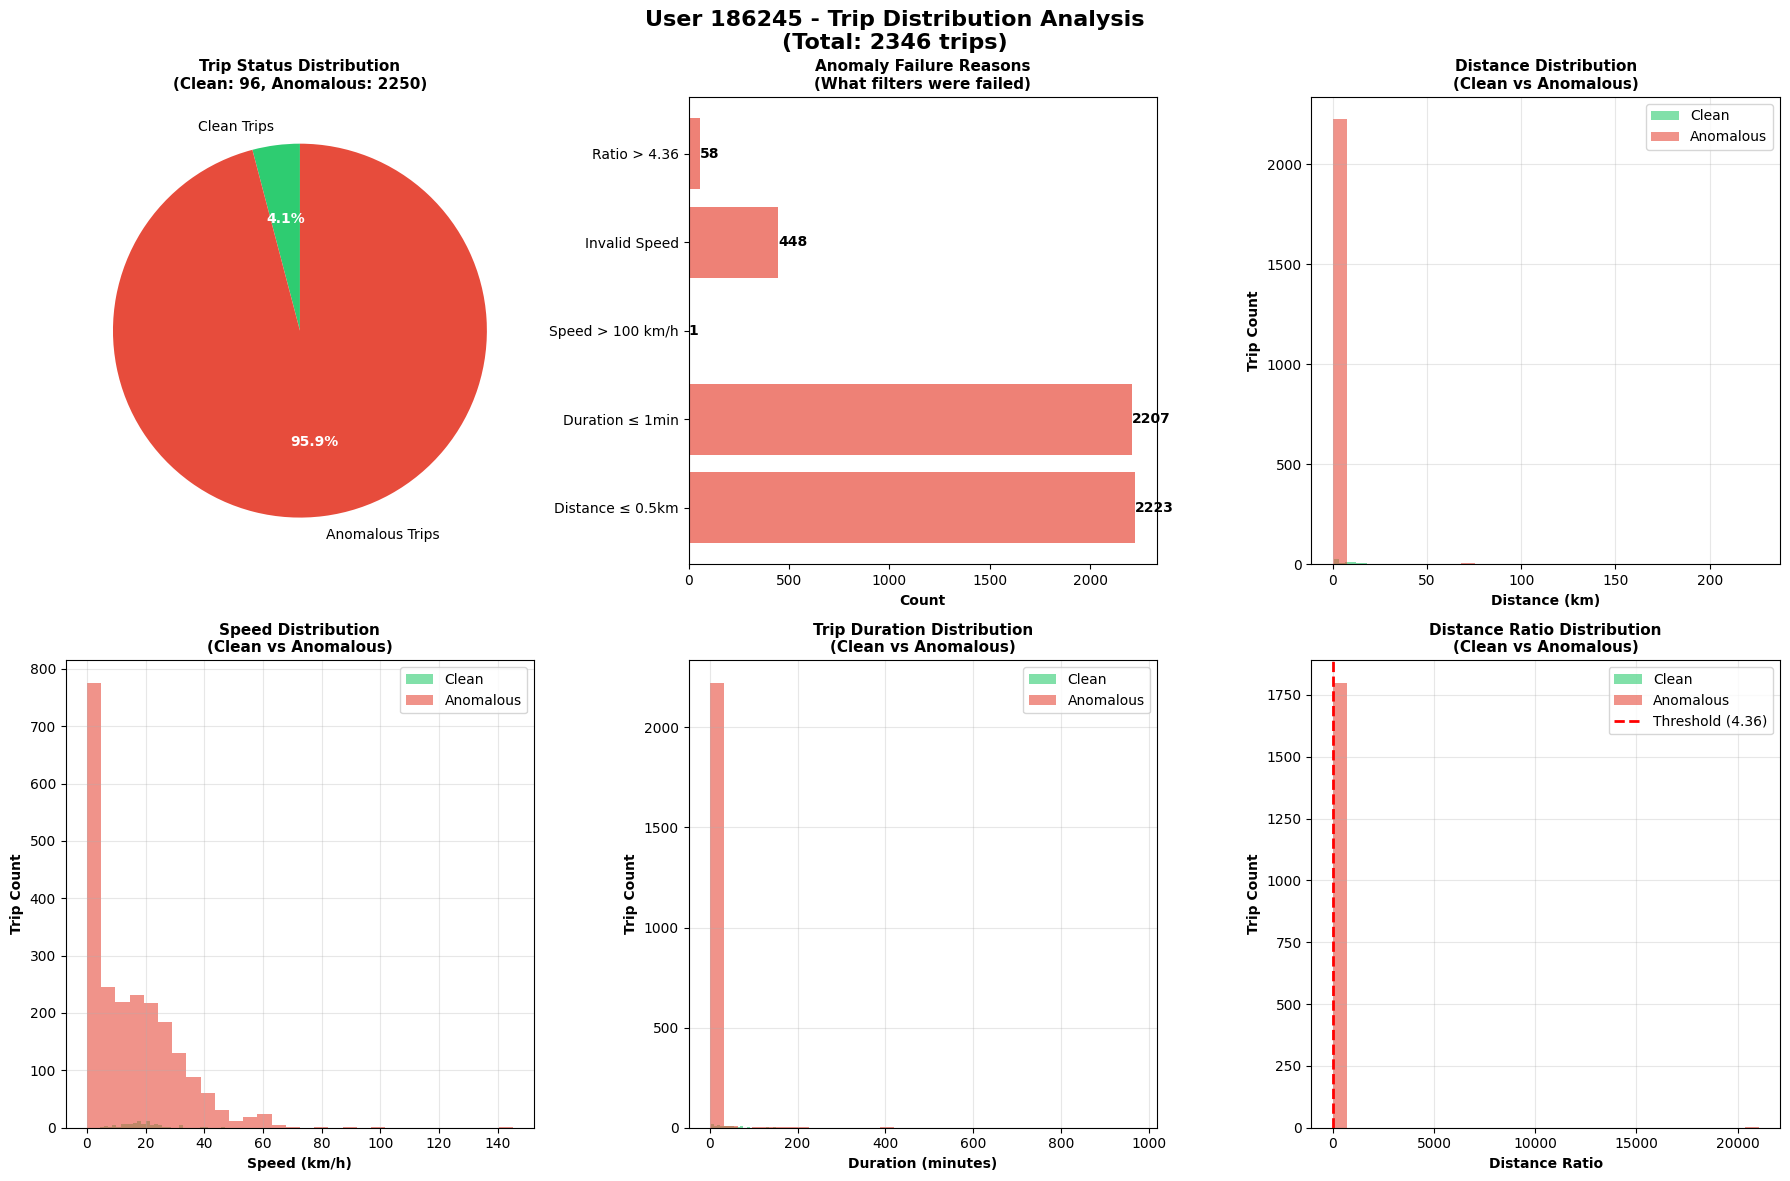

In [16]:
print("\n" + "=" * 100)
print(" " * 25 + "📊 VISUALIZATIONS: USER {}'S TRIP DISTRIBUTION".format(int(top_user_id)))
print("=" * 100)

# Create comprehensive visualization for top user
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'User {int(top_user_id)} - Trip Distribution Analysis\n(Total: {int(top_user_stats["total_trips"])} trips)', 
             fontsize=16, fontweight='bold')

# 1. Anomaly Status Pie Chart
ax1 = axes[0, 0]
anomaly_counts = top_user_trips['anomaly_flag'].value_counts()
labels = ['Clean Trips', 'Anomalous Trips']
sizes = [anomaly_counts.get(0, 0), anomaly_counts.get(1, 0)]
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title(f'Trip Status Distribution\n(Clean: {sizes[0]}, Anomalous: {sizes[1]})', 
              fontweight='bold', fontsize=11)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 2. Anomaly Reasons Breakdown
ax2 = axes[0, 1]
if len(anomalous_trips_user) > 0:
    reasons = {
        'Distance ≤ 0.5km': (anomalous_trips_user['distance'] <= 0.5).sum(),
        'Duration ≤ 1min': (anomalous_trips_user['trip_duration_minutes'] <= 1).sum(),
        'Speed > 100 km/h': (anomalous_trips_user['avg_speed_kmh'] > 100).sum(),
        'Invalid Speed': ((anomalous_trips_user['avg_speed_kmh'] <= 0) | anomalous_trips_user['avg_speed_kmh'].isna()).sum(),
        'trip_seq > 3': (anomalous_trips_user['trip_seq'] > 3).sum(),
        'Ratio > 4.36': (anomalous_trips_user['distance_ratio'] > 4.36).sum()
    }
    reasons = {k: v for k, v in reasons.items() if v > 0}
    if reasons:
        ax2.barh(list(reasons.keys()), list(reasons.values()), color='#e74c3c', alpha=0.7)
        ax2.set_xlabel('Count', fontweight='bold')
        ax2.set_title('Anomaly Failure Reasons\n(What filters were failed)', fontweight='bold', fontsize=11)
        for i, v in enumerate(reasons.values()):
            ax2.text(v + 0.5, i, str(int(v)), va='center', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No Anomalies\nfor This User', ha='center', va='center', fontsize=12, fontweight='bold')
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.axis('off')
else:
    ax2.text(0.5, 0.5, 'No Anomalies\nfor This User', ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')

# 3. Distance Distribution
ax3 = axes[0, 2]
ax3.hist(top_user_trips[top_user_trips['anomaly_flag'] == 0]['distance'], bins=30, alpha=0.6, label='Clean', color='#2ecc71')
ax3.hist(top_user_trips[top_user_trips['anomaly_flag'] == 1]['distance'], bins=30, alpha=0.6, label='Anomalous', color='#e74c3c')
ax3.set_xlabel('Distance (km)', fontweight='bold')
ax3.set_ylabel('Trip Count', fontweight='bold')
ax3.set_title('Distance Distribution\n(Clean vs Anomalous)', fontweight='bold', fontsize=11)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Speed Distribution
ax4 = axes[1, 0]
ax4.hist(top_user_trips[top_user_trips['anomaly_flag'] == 0]['avg_speed_kmh'].dropna(), bins=30, alpha=0.6, label='Clean', color='#2ecc71')
ax4.hist(top_user_trips[top_user_trips['anomaly_flag'] == 1]['avg_speed_kmh'].dropna(), bins=30, alpha=0.6, label='Anomalous', color='#e74c3c')
ax4.set_xlabel('Speed (km/h)', fontweight='bold')
ax4.set_ylabel('Trip Count', fontweight='bold')
ax4.set_title('Speed Distribution\n(Clean vs Anomalous)', fontweight='bold', fontsize=11)
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Trip Duration Distribution
ax5 = axes[1, 1]
ax5.hist(top_user_trips[top_user_trips['anomaly_flag'] == 0]['trip_duration_minutes'], bins=30, alpha=0.6, label='Clean', color='#2ecc71')
ax5.hist(top_user_trips[top_user_trips['anomaly_flag'] == 1]['trip_duration_minutes'], bins=30, alpha=0.6, label='Anomalous', color='#e74c3c')
ax5.set_xlabel('Duration (minutes)', fontweight='bold')
ax5.set_ylabel('Trip Count', fontweight='bold')
ax5.set_title('Trip Duration Distribution\n(Clean vs Anomalous)', fontweight='bold', fontsize=11)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Distance Ratio Distribution
ax6 = axes[1, 2]
ax6.hist(top_user_trips[top_user_trips['anomaly_flag'] == 0]['distance_ratio'], bins=30, alpha=0.6, label='Clean', color='#2ecc71')
ax6.hist(top_user_trips[top_user_trips['anomaly_flag'] == 1]['distance_ratio'], bins=30, alpha=0.6, label='Anomalous', color='#e74c3c')
ax6.axvline(4.36, color='red', linestyle='--', linewidth=2, label='Threshold (4.36)')
ax6.set_xlabel('Distance Ratio', fontweight='bold')
ax6.set_ylabel('Trip Count', fontweight='bold')
ax6.set_title('Distance Ratio Distribution\n(Clean vs Anomalous)', fontweight='bold', fontsize=11)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/top_user_trip_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved to outputs/top_user_trip_distribution.png")
plt.show()

print(f"\n" + "=" * 100)

## Section 10.6: Deep Dive - User with Most "Serious" Anomalies

Analyze the user with the highest count of serious anomalies (Speed > 100 km/h, trip_seq > 3, or distance_ratio > 4.36)
Excludes minor anomalies from short distance or short duration.

In [18]:
print("=" * 100)
print(" " * 15 + "🔴 DEEP DIVE: USER WITH MOST \"SERIOUS\" ANOMALIES")
print("=" * 100)

# Define serious anomalies (excluding short distance and short duration)
df['serious_anomaly_flag'] = (
    (df['avg_speed_kmh'] > 100) |  # High speed
    (df['trip_seq'] > 3) |          # High trip sequence
    (df['distance_ratio'] > 4.36)   # Extreme detour ratio
).astype(int)

# Count serious anomalies per user
serious_anomalies_per_user = df.groupby('user_id')['serious_anomaly_flag'].sum().reset_index()
serious_anomalies_per_user.columns = ['user_id', 'serious_anomaly_count']
serious_anomalies_per_user = serious_anomalies_per_user.sort_values('serious_anomaly_count', ascending=False)

# Find user with most serious anomalies
serious_user_id = serious_anomalies_per_user.iloc[0]['user_id']
serious_user_stats = user_stats[user_stats['user_id'] == serious_user_id].iloc[0]
serious_anomaly_count = serious_anomalies_per_user.iloc[0]['serious_anomaly_count']

print(f"\n📊 User with Most Serious Anomalies: User {int(serious_user_id)}")
print(f"  • Total trips: {int(serious_user_stats['total_trips'])}")
print(f"  • Clean trips: {int(serious_user_stats['clean_trips'])}")
print(f"  • Total anomalous trips: {int(serious_user_stats['anomalous_trips'])}")
print(f"  • Serious anomalies (Speed>100, seq>3, ratio>4.36): {int(serious_anomaly_count)}")
print(f"  • Serious anomaly rate: {(serious_anomaly_count / serious_user_stats['total_trips'] * 100):.2f}%")
print(f"  • Overall anomaly rate: {serious_user_stats['anomaly_rate']:.2f}%")
print(f"  • Infection status: {serious_user_stats['infection_status']}")
print(f"  • Risk category: {serious_user_stats['risk_category']}")

# Get all trips for this user
serious_user_trips = df[df['user_id'] == serious_user_id].copy()

print(f"\n📈 Trip Distribution for User {int(serious_user_id)}:")
print(f"  • Total records: {len(serious_user_trips):,}")
print(f"  • Clean (no anomalies): {(serious_user_trips['anomaly_flag'] == 0).sum():,}")
print(f"  • Anomalous trips: {(serious_user_trips['anomaly_flag'] == 1).sum():,}")
print(f"  • Serious anomalies: {(serious_user_trips['serious_anomaly_flag'] == 1).sum():,}")

# Breakdown of serious anomalies
serious_trips_user = serious_user_trips[serious_user_trips['serious_anomaly_flag'] == 1].copy()

print(f"\n🚩 Serious Anomaly Breakdown for User {int(serious_user_id)}:")
if len(serious_trips_user) > 0:
    high_speed = (serious_trips_user['avg_speed_kmh'] > 100).sum()
    high_seq = (serious_trips_user['trip_seq'] > 3).sum()
    high_ratio = (serious_trips_user['distance_ratio'] > 4.36).sum()
    
    print(f"  • Speed > 100 km/h: {high_speed}")
    print(f"  • trip_seq > 3: {high_seq}")
    print(f"  • distance_ratio > 4.36: {high_ratio}")
else:
    print(f"  • User has no serious anomalies (might be all short distance/duration)")


               🔴 DEEP DIVE: USER WITH MOST "SERIOUS" ANOMALIES

📊 User with Most Serious Anomalies: User 182701
  • Total trips: 1082
  • Clean trips: 473
  • Total anomalous trips: 609
  • Serious anomalies (Speed>100, seq>3, ratio>4.36): 366
  • Serious anomaly rate: 33.83%
  • Overall anomaly rate: 56.28%
  • Infection status: INFECTED
  • Risk category: ORANGE

📈 Trip Distribution for User 182701:
  • Total records: 1,082
  • Clean (no anomalies): 473
  • Anomalous trips: 609
  • Serious anomalies: 366

🚩 Serious Anomaly Breakdown for User 182701:
  • Speed > 100 km/h: 0
  • trip_seq > 3: 0
  • distance_ratio > 4.36: 366



                    📊 VISUALIZATIONS: USER 182701'S SERIOUS ANOMALIES

✅ Visualization saved to outputs/serious_anomalies_user_distribution.png


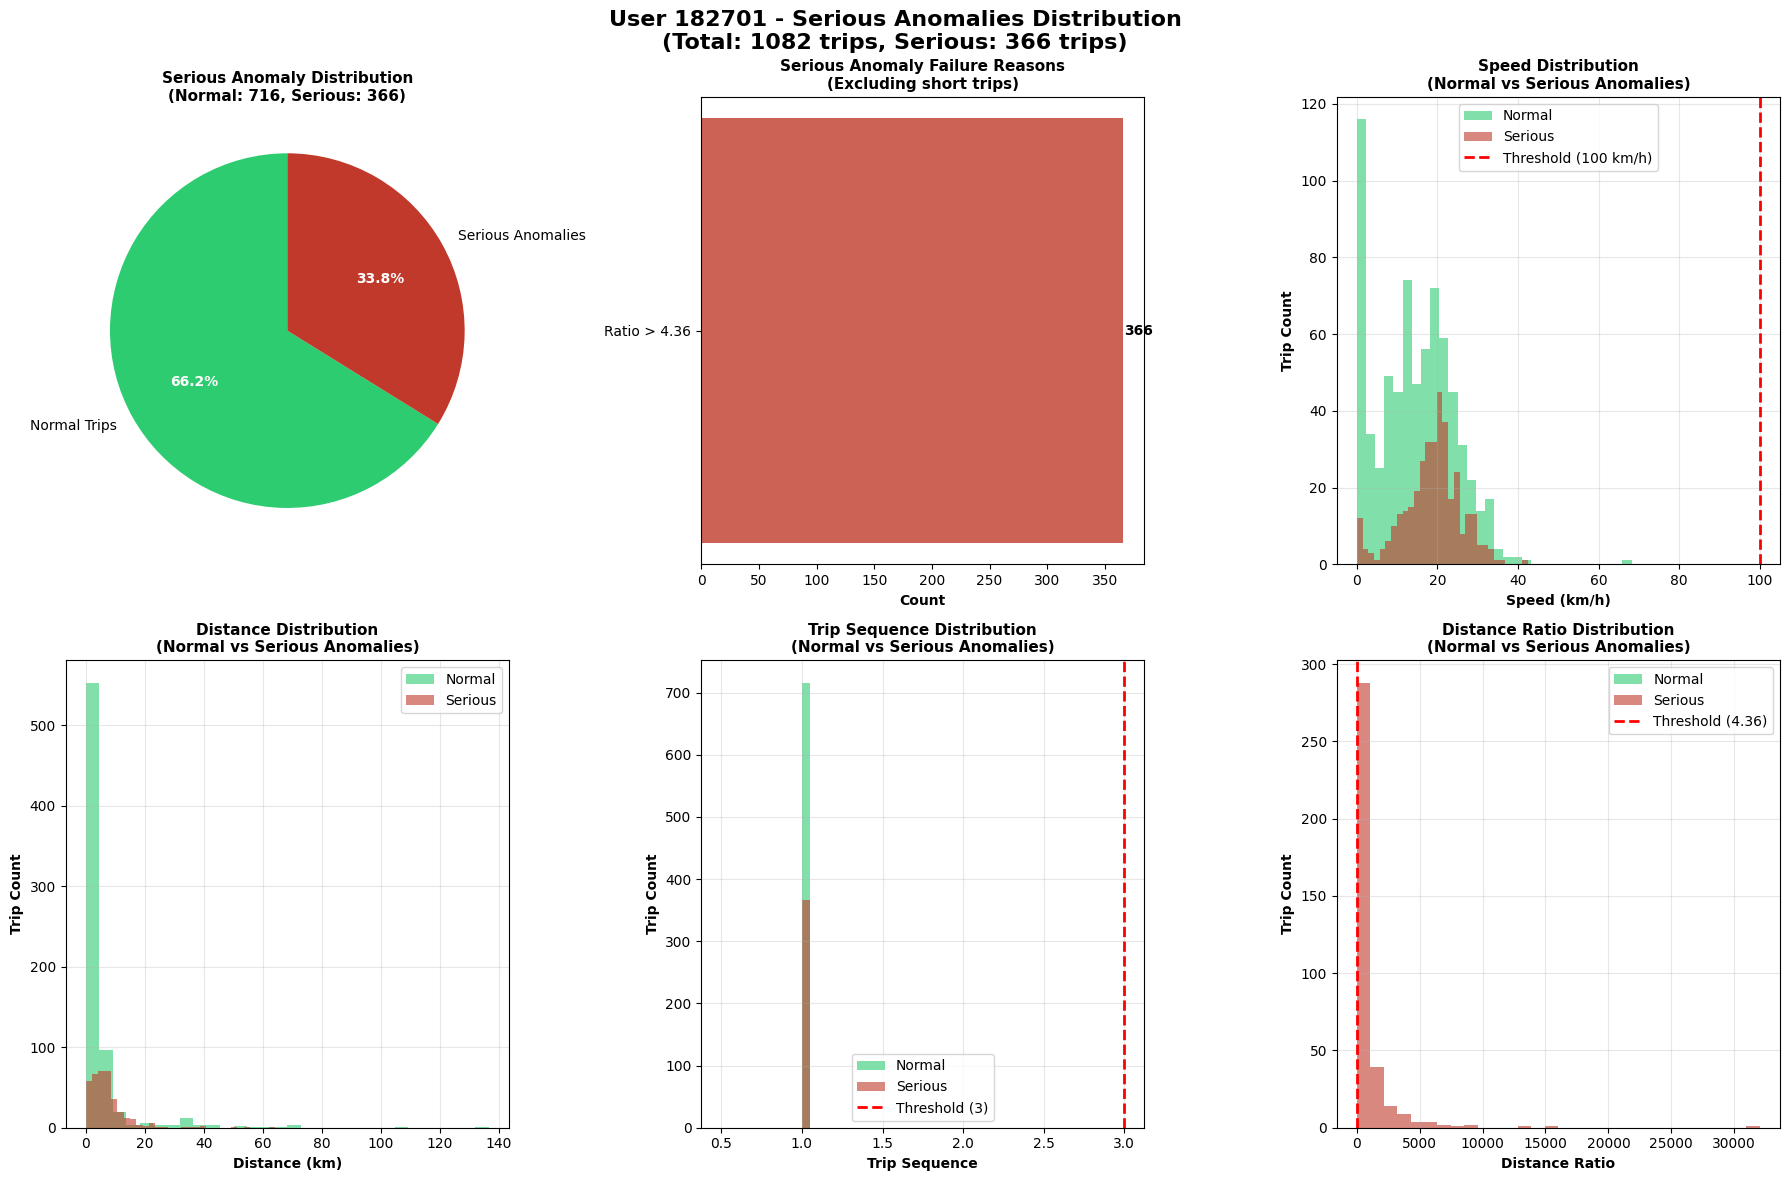

In [19]:
print("\n" + "=" * 100)
print(" " * 20 + "📊 VISUALIZATIONS: USER {}'S SERIOUS ANOMALIES".format(int(serious_user_id)))
print("=" * 100)

# Create comprehensive visualization for serious anomalies user
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'User {int(serious_user_id)} - Serious Anomalies Distribution\n(Total: {int(serious_user_stats["total_trips"])} trips, Serious: {int(serious_anomaly_count)} trips)', 
             fontsize=16, fontweight='bold')

# 1. Serious Anomaly Status Pie Chart
ax1 = axes[0, 0]
serious_counts = serious_user_trips['serious_anomaly_flag'].value_counts()
labels = ['Normal Trips', 'Serious Anomalies']
sizes = [serious_counts.get(0, 0), serious_counts.get(1, 0)]
colors = ['#2ecc71', '#c0392b']  # Light green and dark red for serious
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title(f'Serious Anomaly Distribution\n(Normal: {sizes[0]}, Serious: {sizes[1]})', 
              fontweight='bold', fontsize=11)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 2. Serious Anomaly Reasons Breakdown
ax2 = axes[0, 1]
if len(serious_trips_user) > 0:
    reasons = {
        'Speed > 100 km/h': (serious_trips_user['avg_speed_kmh'] > 100).sum(),
        'trip_seq > 3': (serious_trips_user['trip_seq'] > 3).sum(),
        'Ratio > 4.36': (serious_trips_user['distance_ratio'] > 4.36).sum()
    }
    reasons = {k: v for k, v in reasons.items() if v > 0}
    if reasons:
        ax2.barh(list(reasons.keys()), list(reasons.values()), color='#c0392b', alpha=0.8)
        ax2.set_xlabel('Count', fontweight='bold')
        ax2.set_title('Serious Anomaly Failure Reasons\n(Excluding short trips)', fontweight='bold', fontsize=11)
        for i, v in enumerate(reasons.values()):
            ax2.text(v + 0.5, i, str(int(v)), va='center', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No Serious Anomalies\nfor This User', ha='center', va='center', fontsize=12, fontweight='bold')
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.axis('off')
else:
    ax2.text(0.5, 0.5, 'No Serious Anomalies\nfor This User', ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')

# 3. Speed Distribution
ax3 = axes[0, 2]
normal_trips = serious_user_trips[serious_user_trips['serious_anomaly_flag'] == 0]
serious_speed = serious_user_trips[serious_user_trips['serious_anomaly_flag'] == 1]
ax3.hist(normal_trips['avg_speed_kmh'].dropna(), bins=30, alpha=0.6, label='Normal', color='#2ecc71')
ax3.hist(serious_speed['avg_speed_kmh'].dropna(), bins=30, alpha=0.6, label='Serious', color='#c0392b')
ax3.axvline(100, color='red', linestyle='--', linewidth=2, label='Threshold (100 km/h)')
ax3.set_xlabel('Speed (km/h)', fontweight='bold')
ax3.set_ylabel('Trip Count', fontweight='bold')
ax3.set_title('Speed Distribution\n(Normal vs Serious Anomalies)', fontweight='bold', fontsize=11)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Distance Distribution
ax4 = axes[1, 0]
ax4.hist(normal_trips['distance'], bins=30, alpha=0.6, label='Normal', color='#2ecc71')
ax4.hist(serious_speed['distance'], bins=30, alpha=0.6, label='Serious', color='#c0392b')
ax4.set_xlabel('Distance (km)', fontweight='bold')
ax4.set_ylabel('Trip Count', fontweight='bold')
ax4.set_title('Distance Distribution\n(Normal vs Serious Anomalies)', fontweight='bold', fontsize=11)
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Trip Sequence Distribution
ax5 = axes[1, 1]
ax5.hist(normal_trips['trip_seq'], bins=20, alpha=0.6, label='Normal', color='#2ecc71')
ax5.hist(serious_speed['trip_seq'], bins=20, alpha=0.6, label='Serious', color='#c0392b')
ax5.axvline(3, color='red', linestyle='--', linewidth=2, label='Threshold (3)')
ax5.set_xlabel('Trip Sequence', fontweight='bold')
ax5.set_ylabel('Trip Count', fontweight='bold')
ax5.set_title('Trip Sequence Distribution\n(Normal vs Serious Anomalies)', fontweight='bold', fontsize=11)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Distance Ratio Distribution
ax6 = axes[1, 2]
ax6.hist(normal_trips['distance_ratio'].dropna(), bins=30, alpha=0.6, label='Normal', color='#2ecc71')
ax6.hist(serious_speed['distance_ratio'].dropna(), bins=30, alpha=0.6, label='Serious', color='#c0392b')
ax6.axvline(4.36, color='red', linestyle='--', linewidth=2, label='Threshold (4.36)')
ax6.set_xlabel('Distance Ratio', fontweight='bold')
ax6.set_ylabel('Trip Count', fontweight='bold')
ax6.set_title('Distance Ratio Distribution\n(Normal vs Serious Anomalies)', fontweight='bold', fontsize=11)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/serious_anomalies_user_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved to outputs/serious_anomalies_user_distribution.png")
plt.show()

print(f"\n" + "=" * 100)

## Section 11: Export Results to CSV

In [ ]:
import os

# Create output directory if it doesn't exist
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

# Timestamp for exports
export_timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("=" * 100)
print(" " * 35 + "📁 EXPORTING RESULTS")
print("=" * 100)

# 1. Export full user stats
export_file_full = f'{output_dir}/user_anomaly_stats_full_{export_timestamp}.csv'
user_stats.to_csv(export_file_full, index=False)
print(f"\n✅ Full user statistics exported")
print(f"   📂 File: {export_file_full}")
print(f"   📊 Records: {len(user_stats):,} users")
print(f"   📋 Columns: {len(user_stats.columns)}")

# 2. Export INFECTED users only
export_file_infected = f'{output_dir}/user_anomaly_stats_infected_only_{export_timestamp}.csv'
infected.to_csv(export_file_infected, index=False)
print(f"\n✅ Infected users exported")
print(f"   📂 File: {export_file_infected}")
print(f"   📊 Records: {len(infected):,} users")

# 3. Export RED risk users (highest priority)
red_risk = user_stats[user_stats['risk_category'] == 'RED']
export_file_red = f'{output_dir}/user_anomaly_stats_red_risk_{export_timestamp}.csv'
red_risk.to_csv(export_file_red, index=False)
print(f"\n✅ RED risk users exported (highest priority)")
print(f"   📂 File: {export_file_red}")
print(f"   📊 Records: {len(red_risk):,} users")

# 4. Export summary statistics
summary_stats = {
    'Metric': [
        'Total Users',
        'NOT_INFECTED Users',
        'INFECTED Users',
        'Total Trips',
        'Clean Trips',
        'Anomalous Trips',
        'Overall Anomaly Rate %',
        'Infected Users - Min Anomaly Rate %',
        'Infected Users - Max Anomaly Rate %',
        'Infected Users - Mean Anomaly Rate %',
        'Infected Users - Median Anomaly Rate %'
    ],
    'Value': [
        len(user_stats),
        len(not_infected),
        len(infected),
        user_stats['total_trips'].sum(),
        user_stats['clean_trips'].sum(),
        user_stats['anomalous_trips'].sum(),
        round((user_stats['anomalous_trips'].sum() / user_stats['total_trips'].sum() * 100), 2),
        round(infected['anomaly_rate'].min(), 2),
        round(infected['anomaly_rate'].max(), 2),
        round(infected['anomaly_rate'].mean(), 2),
        round(infected['anomaly_rate'].median(), 2)
    ]
}

summary_df = pd.DataFrame(summary_stats)
export_file_summary = f'{output_dir}/user_anomaly_summary_{export_timestamp}.csv'
summary_df.to_csv(export_file_summary, index=False)
print(f"\n✅ Summary statistics exported")
print(f"   📂 File: {export_file_summary}")

print(f"\n" + "=" * 100)
print(f" " * 30 + "✨ USER ANALYSIS COMPLETE - ALL RESULTS SAVED ✨")
print(f"=" * 100)

## Section 12: Summary & Conclusions

In [17]:
print("\n" + "=" * 100)
print(" " * 35 + "📊 FINAL SUMMARY REPORT")
print("=" * 100)

print(f"\n🎯 KEY FINDINGS:")
print(f"\n1️⃣ INFECTION STATUS:")
print(f"   • NOT_INFECTED users: {len(not_infected):,} ({len(not_infected)/len(user_stats)*100:.1f}%)")
print(f"     - These users have 100% clean trips - no anomalies detected")
print(f"   • INFECTED users: {len(infected):,} ({len(infected)/len(user_stats)*100:.1f}%)")
print(f"     - These users have at least 1 anomalous trip")

print(f"\n2️⃣ ANOMALY RATE STATISTICS (Infected users only):")
print(f"   • Minimum: {infected['anomaly_rate'].min():.2f}%")
print(f"   • Maximum: {infected['anomaly_rate'].max():.2f}%")
print(f"   • Mean: {infected['anomaly_rate'].mean():.2f}%")
print(f"   • Median: {infected['anomaly_rate'].median():.2f}%")
print(f"   • Std Dev: {infected['anomaly_rate'].std():.2f}%")

print(f"\n3️⃣ RISK STRATIFICATION (Infected users only):")
for category in ['GREEN', 'YELLOW', 'ORANGE', 'RED']:
    count = len(infected[infected['risk_category'] == category])
    pct = count / len(infected) * 100 if len(infected) > 0 else 0
    print(f"   • {category}: {count:,} users ({pct:.1f}%)")

print(f"\n4️⃣ TRIP DISTRIBUTION:")
print(f"   • Total trips: {user_stats['total_trips'].sum():,}")
print(f"   • Clean trips: {user_stats['clean_trips'].sum():,} ({user_stats['clean_trips'].sum()/user_stats['total_trips'].sum()*100:.1f}%)")
print(f"   • Anomalous trips: {user_stats['anomalous_trips'].sum():,} ({user_stats['anomalous_trips'].sum()/user_stats['total_trips'].sum()*100:.1f}%)")

print(f"\n5️⃣ HIGHEST RISK USERS:")
top_5_red = user_stats[user_stats['risk_category'] == 'RED'].head(5)
if len(top_5_red) > 0:
    for idx, (_, row) in enumerate(top_5_red.iterrows(), 1):
        print(f"   {idx}. User {int(row['user_id'])} - {row['anomaly_rate']:.1f}% anomaly rate ({int(row['anomalous_trips'])}/{int(row['total_trips'])} trips)")
else:
    print(f"   • No users in RED risk category")

print(f"\n" + "=" * 100)
print(f" " * 20 + "✅ ANALYSIS READY FOR INVESTIGATION & DECISION MAKING ✅")
print(f"=" * 100)


                                   📊 FINAL SUMMARY REPORT

🎯 KEY FINDINGS:

1️⃣ INFECTION STATUS:
   • NOT_INFECTED users: 34 (4.0%)
     - These users have 100% clean trips - no anomalies detected
   • INFECTED users: 825 (96.0%)
     - These users have at least 1 anomalous trip

2️⃣ ANOMALY RATE STATISTICS (Infected users only):
   • Minimum: 3.57%
   • Maximum: 100.00%
   • Mean: 74.76%
   • Median: 100.00%
   • Std Dev: 31.62%

3️⃣ RISK STRATIFICATION (Infected users only):
   • GREEN: 51 users (6.2%)
   • YELLOW: 180 users (21.8%)
   • ORANGE: 109 users (13.2%)
   • RED: 485 users (58.8%)

4️⃣ TRIP DISTRIBUTION:
   • Total trips: 61,345
   • Clean trips: 31,296 (51.0%)
   • Anomalous trips: 30,049 (49.0%)

5️⃣ HIGHEST RISK USERS:
   1. User 24142 - 100.0% anomaly rate (1/1 trips)
   2. User 12271 - 100.0% anomaly rate (19/19 trips)
   3. User 12399 - 100.0% anomaly rate (22/22 trips)
   4. User 12390 - 100.0% anomaly rate (26/26 trips)
   5. User 12380 - 100.0% anomaly rate (23/2